### Create the LunarLander environment

In [1]:
import pandas as pd
import numpy as np
import gym

env = gym.make("LunarLander-v2")

### Setup R packages

In [2]:
from cxrl.lib.r_to_py import setup_R
setup_R()

[]


### A sample policy for LunarLander

In [3]:
def policy(state):
    """
    state:
        x, y, vx, vy, angle, angular_velocity, left_contact, right_contact

    returns:
        action in {0, 1, 2, 3}
    """
    x, y, vx, vy, angle, angular_velocity, left_contact, right_contact = state

    target_angle = 0.5 * x + 1.0 * vx
    target_angle = np.clip(target_angle, -0.4, 0.4)

    target_y = 0.55 * abs(x)

    angle_control = 0.5 * (target_angle - angle) - 1.0 * angular_velocity
    hover_control = 0.5 * (target_y - y) - 0.5 * vy

    if left_contact or right_contact:
        angle_control = 0.0
        hover_control = -0.5 * vy

    if hover_control > abs(angle_control) and hover_control > 0.05:
        return 2      # main engine
    elif angle_control < -0.05:
        return 3      # right orientation engine
    elif angle_control > 0.05:
        return 1      # left orientation engine
    else:
        return 0      # do nothing

### Infer the global causal graph from episodes (label encoding action)

In [4]:
from cxrl.lib.xrl import XRL
# names for interpretable representations
feature_names = ['x', 'y', 'vx', 'vy', 'angle', 'angular_velocity', 'left_contact', 'right_contact', 'action']
xrl = XRL(env, pi=policy, repr_names=feature_names, verbose=True, one_hot_actions=False, repr_integration=False, nepisodes=5)

experience size= 1177
 causes: ['x'] -> x
 causes: ['y'] -> y
 causes: ['vx', 'action'] -> vx
 causes: ['y', 'vy'] -> vy
 causes: ['angle', 'angular_velocity'] -> angle
 causes: ['angle', 'angular_velocity', 'right_contact'] -> angular_velocity
 causes: ['y', 'left_contact', 'right_contact'] -> left_contact
 causes: ['y', 'left_contact', 'right_contact'] -> right_contact
 causes: ['angle', 'right_contact', 'action'] -> action
BART SLA elapsed time: 0.0 seconds


### Infer the local causal graph from given state (state at game step 500)

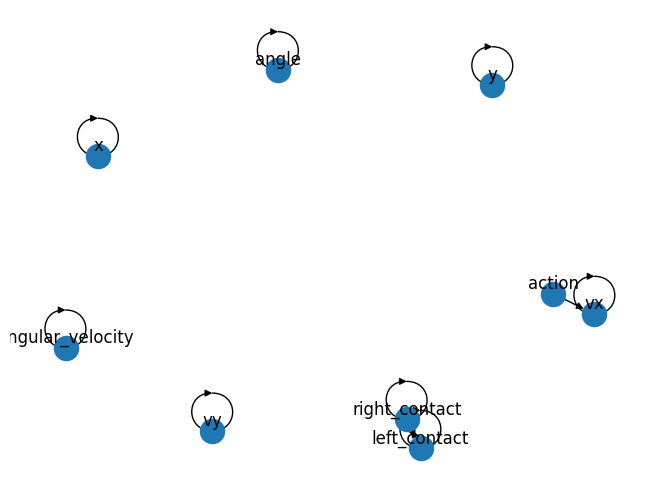

In [5]:
step = 500
# tuple of states, actions, rewards, states_new
states, actions, rewards, states_new = xrl.replay_buffer

from cxrl.lib.utils import convert_and_expand
states = convert_and_expand(states).astype(float)
actions = convert_and_expand(actions).astype(float)

replay = pd.DataFrame(np.concatenate((states, actions), axis=1), columns=feature_names)

query = replay[step:step+1]
localG = xrl.local_causal_network(query)
xrl.render_network(localG)

### Infer the global causal graph from episodes (action one-hot encoding)

In [ ]:
from cxrl.lib.xrl import XRL
# names for interpretable representations (states and actions)
feature_names = ['x', 'y', 'vx', 'vy', 'angle', 'angular_velocity', 'left_contact', 'right_contact', 'do_nothing', 'fire_left_engine', 'fire_main_engine', 'fire_right_engine']
xrl = XRL(env, pi=policy, repr_names=feature_names, verbose=True, one_hot_actions=True, repr_integration=False, nepisodes=10)

experience size= 6074
 causes: ['cart_position', 'cart_velocity'] -> cart_position
 causes: ['cart_velocity', 'push'] -> cart_velocity
 causes: ['pole_angle', 'pole_velocity'] -> pole_angle
 causes: ['cart_velocity', 'pole_angle', 'pole_velocity', 'push'] -> pole_velocity
 causes: ['cart_position', 'pole_angle', 'push'] -> push
BART SLA elapsed time: 0.0 seconds
